Test image:

![Test Image](p28swimming.png)

In [56]:
# IMPORTS
import cv2
import numpy as np
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(1918.5), np.float64(718.5), np.float64(-0.5))

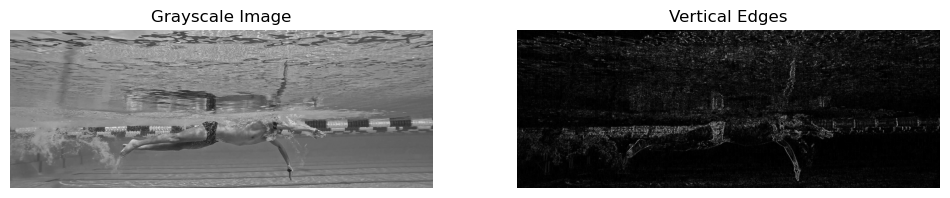

In [57]:
img_path = 'p28swimming.png'
# Read the image
img = cv2.imread(img_path)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Use the Sobel operator to find vertical edges (detect changes in the x direction)
sobelx_gray = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
vertical_edges_gray = np.uint8(np.absolute(sobelx_gray))

# Display the grayscale image and vertical edges side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(gray, cmap='gray')
axs[0].set_title('Grayscale Image')
axs[0].axis('off')
axs[1].imshow(vertical_edges_gray, cmap='gray')
axs[1].set_title('Vertical Edges')
axs[1].axis('off')


(np.float64(-0.5), np.float64(1918.5), np.float64(718.5), np.float64(-0.5))

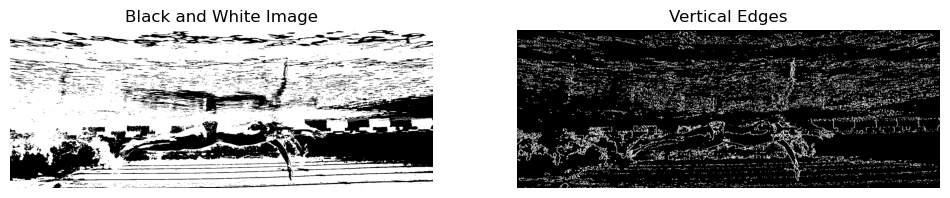

In [58]:
# convert the gray to black and white
_, bnw = cv2.threshold(gray, 128, 255, cv2.THRESH_BINARY)

# Use the Sobel operator to find vertical edges (detect changes in the x direction)
sobelx_bnw = cv2.Sobel(bnw, cv2.CV_64F, 1, 0, ksize=3)
vertical_edges_bnw = np.uint8(np.absolute(sobelx_bnw))

# Display the grayscale image and vertical edges side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(bnw, cmap='gray')
axs[0].set_title('Black and White Image')
axs[0].axis('off')
axs[1].imshow(vertical_edges_bnw, cmap='gray')
axs[1].set_title('Vertical Edges')
axs[1].axis('off')

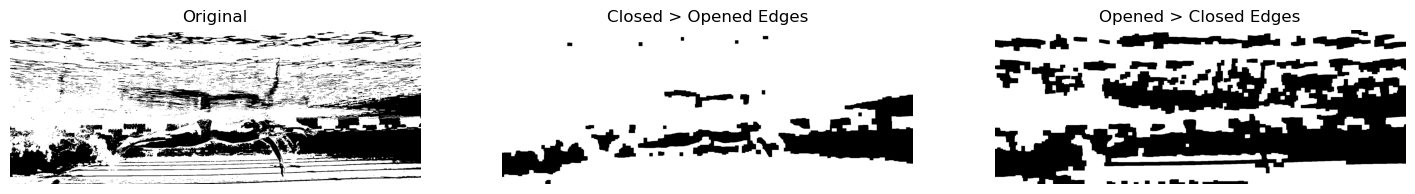

In [64]:
# perform closing to fill in gaps in the lane ropes
kernel = np.ones((15, 15), np.uint8)
closed_edges = cv2.morphologyEx(bnw, cv2.MORPH_CLOSE, kernel)
opened_closed_edges = cv2.morphologyEx(closed_edges, cv2.MORPH_OPEN, kernel)

#  perform opening to remove small noise
opened_edges = cv2.morphologyEx(bnw, cv2.MORPH_OPEN, kernel)
closed_opened_edges = cv2.morphologyEx(opened_edges, cv2.MORPH_CLOSE, kernel)

# Display the results
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
axs[0].imshow(bnw, cmap='gray')
axs[0].set_title('Original')
axs[0].axis('off')

axs[1].imshow(opened_closed_edges, cmap='gray')
axs[1].set_title('Closed > Opened Edges')
axs[1].axis('off')

axs[2].imshow(closed_opened_edges, cmap='gray')
axs[2].set_title('Opened > Closed Edges')
axs[2].axis('off')

plt.show()

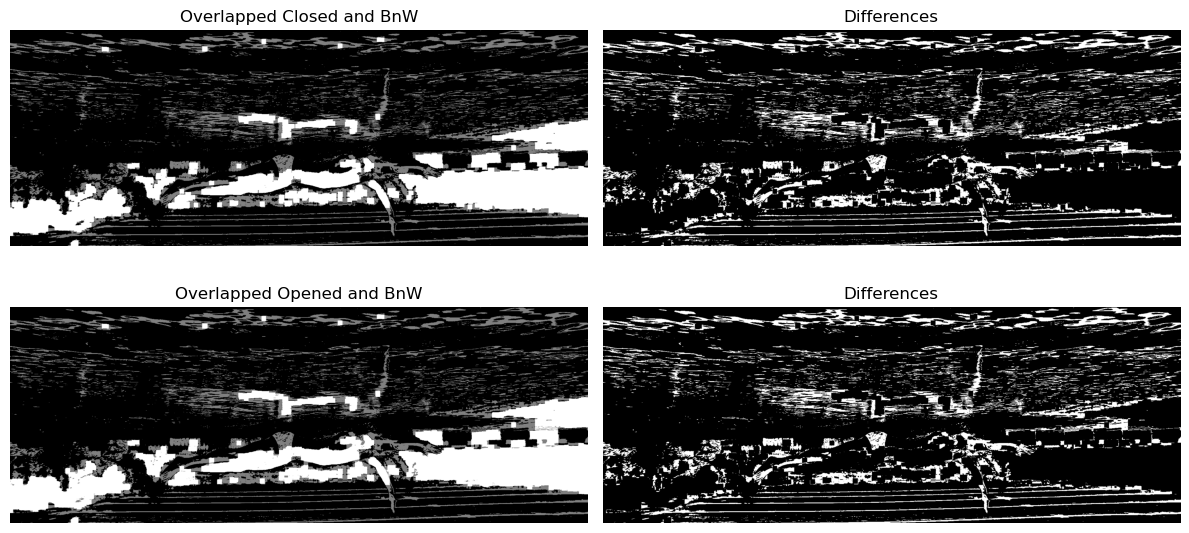

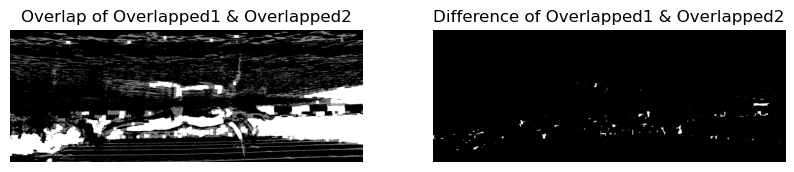

In [69]:
# overlap the closed and bnw to see how much the lane ropes are modified
overlapped1 = cv2.addWeighted(cv2.bitwise_not(
    closed_edges), 0.5, cv2.bitwise_not(bnw), 0.5, 0)
overlapped2 = cv2.addWeighted(cv2.bitwise_not(
    opened_closed_edges), 0.5, cv2.bitwise_not(bnw), 0.5, 0)

# differences
differences1 = cv2.absdiff(closed_edges, bnw)
differences2 = cv2.absdiff(opened_closed_edges, bnw)

# Display the results
fig, axs = plt.subplots(2, 2, figsize=(12, 6))
axs[0][0].imshow(overlapped1, cmap='gray')
axs[0][0].set_title('Overlapped Closed and BnW')
axs[0][0].axis('off')
axs[0][1].imshow(differences1, cmap='gray')
axs[0][1].set_title('Differences')
axs[0][1].axis('off')
axs[1][0].imshow(overlapped2, cmap='gray')
axs[1][0].set_title('Overlapped Opened and BnW')
axs[1][0].axis('off')
axs[1][1].imshow(differences2, cmap='gray')
axs[1][1].set_title('Differences')
axs[1][1].axis('off')

fig.tight_layout()
plt.show()

# Plot overlap and difference between overlapped1 and overlapped2
overlap_img = cv2.addWeighted(overlapped1, 0.5, overlapped2, 0.5, 0)
diff_img = cv2.absdiff(overlapped1, overlapped2)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(overlap_img, cmap='gray')
axs[0].set_title('Overlap of Overlapped1 & Overlapped2')
axs[0].axis('off')
axs[1].imshow(diff_img, cmap='gray')
axs[1].set_title('Difference of Overlapped1 & Overlapped2')
axs[1].axis('off')
plt.show()

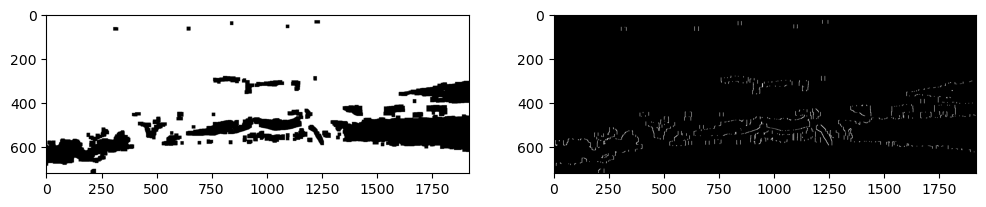

In [61]:
# sobel x on closed img

sobelx_closed = cv2.Sobel(closed_edges, cv2.CV_64F, 1, 0, ksize=3)
vertical_edges_closed = np.uint8(np.absolute(sobelx_closed))
# Display the grayscale image and vertical edges side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(closed_edges, cmap='gray')
axs[1].imshow(vertical_edges_closed, cmap='gray')

Text(0.5, 1.0, 'Overlapping Vertical Edges (15 & 5 Kernel)')

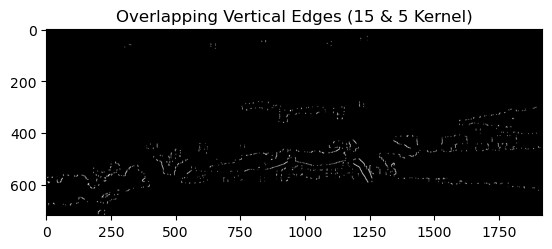

In [62]:
#  compare 15 and 5 kernel size for closing

# closing for 5 kernel
kernel = np.ones((5, 5), np.uint8)
closed_edges_5 = cv2.morphologyEx(bnw, cv2.MORPH_CLOSE, kernel)

#  sobel x on closed img with 5 kernel
sobelx_closed_5 = cv2.Sobel(closed_edges_5, cv2.CV_64F, 1, 0, ksize=3)
vertical_edges_closed_5 = np.uint8(np.absolute(sobelx_closed_5))

# overlap the 15 and 5 kernel to highlight only the overlapping (common) parts
overlap_mask = cv2.bitwise_and(vertical_edges_closed, vertical_edges_closed_5)
plt.imshow(overlap_mask, cmap='gray')
plt.title('Overlapping Vertical Edges (15 & 5 Kernel)')